## Python For Machine Learning Fall 2025
---
# Ensemble Learning

Ensemble Methods: Going Beyond a Single Decision Tree

If you examine machine learning applications, you will notice the widespread use of tree-based classification and regression models. This is surprising because the CART model we presented is fundamentally simple. While the interpretability of these models is a key benefit, it is not enough to overcome their performance disadvantages.

## 1. Why the CART Algorithm is Unstable？

The primary reason for the instability of the CART algorithm is that it's a greedy algorithm, which leads to a model with high variance.

Here's what that means:

Greedy Nature: At each step of building the tree, the CART algorithm searches for the single best split (feature and threshold) at that particular moment. It only considers how to achieve the highest purity (e.g., the lowest Gini impurity) for the current node, without considering the global consequences for the entire tree.

Sensitivity to Data: Because of this greedy approach, the algorithm is highly sensitive to small changes in the training data. A minor perturbation, addition, or removal of a data point can cause the "best" split at a given node to change.

The Domino Effect: Once an upper-level node in the tree (especially the root node) changes its splitting rule, the entire structure of the sub-trees below it can change dramatically. This change cascades down the tree like a line of dominos, resulting in a completely different final tree structure.

In short, a decision tree's "short-sighted" focus on the immediate best split makes it prone to "indecisiveness," where it can change its entire structure based on tiny data variations.

Here, we present a simple code example to demonstrate the instability of CART.

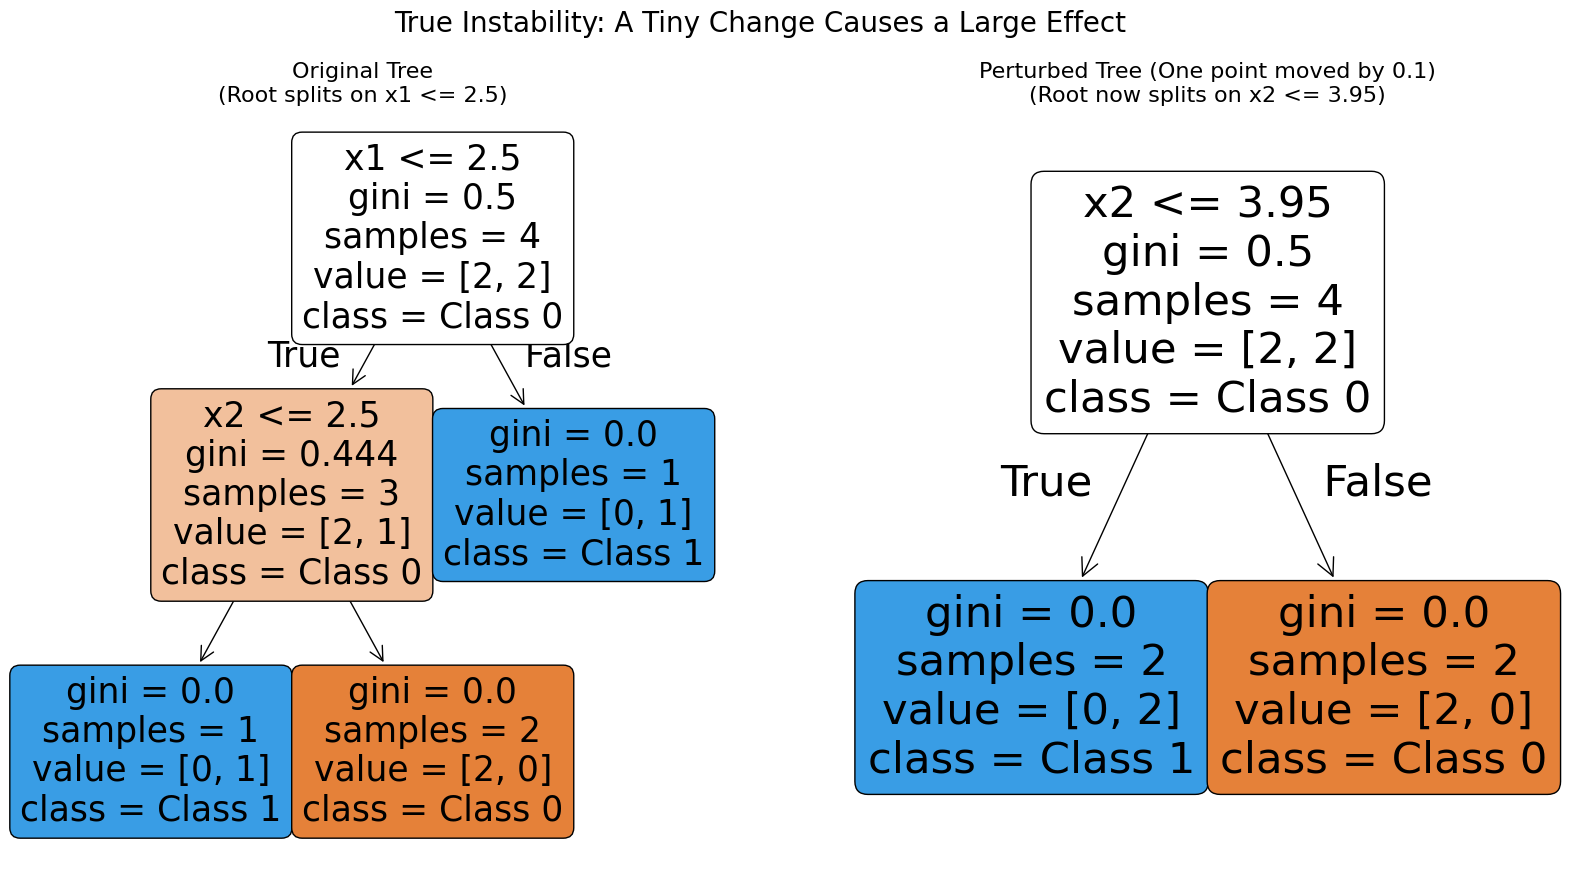

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# In this specific arrangement, the Gini impurity reduction for splitting on x1 vs. x2 is
# exactly tied. Scikit-learn's implementation breaks this tie by choosing the first feature, x1.
X_original = np.array([
    [1, 4], [2, 4],  # Class 0 (Blue)
    [3, 4], [1, 1],  # Class 1 (Orange)
])
y_original = np.array([0, 0, 1, 1])

# We take ONE point, (3, 4), and move it just a little bit to (3, 3.9).
# This change is tiny, but it's enough to break the tie in favor of an x2 split.
X_perturbed = np.array([
    [1, 4], [2, 4],      # Class 0 (Blue)
    [3, 3.9], [1, 1],    # Class 1 (Orange) - one point slightly moved
])
y_perturbed = y_original # Labels do not change

tree_original = DecisionTreeClassifier(random_state=42)
tree_original.fit(X_original, y_original)

tree_perturbed = DecisionTreeClassifier(random_state=42)
tree_perturbed.fit(X_perturbed, y_perturbed)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))
plt.suptitle("True Instability: A Tiny Change Causes a Large Effect", fontsize=20, y=0.98)

# Visualize the trees.
plot_tree(tree_original,
          feature_names=['x1', 'x2'],
          class_names=['Class 0', 'Class 1'],
          filled=True,
          rounded=True,
          ax=axes[0])
axes[0].set_title("Original Tree\n(Root splits on x1 <= 2.5)", fontsize=16)

plot_tree(tree_perturbed,
          feature_names=['x1', 'x2'],
          class_names=['Class 0', 'Class 1'],
          filled=True,
          rounded=True,
          ax=axes[1])
axes[1].set_title("Perturbed Tree (One point moved by 0.1)\n(Root now splits on x2 <= 3.95)", fontsize=16)

plt.show()

## 2. Ensemble Method


### 2.1 Overview

Although a single decision tree is easy to understand, it has two major weaknesses. First, it has high variance, meaning small changes in training data can create a completely different model, making it unstable. Second, it is prone to overfitting, where it learns noise from the training data and then performs poorly on new data. Ensemble methods fix these issues by combining predictions from many models. This "wisdom of the crowd" approach reduces instability and overfitting, leading to a more accurate model.

### 2.2 Bias and Variance

In machine learning, bias and variance are two fundamental types of error that a model can make. Understanding them is crucial for diagnosing model problems and building effective predictors.

- Bias is the error from a model's overly simple assumptions. High bias means the model fails to capture the underlying patterns in the data, leading to underfitting.

- Variance is the error from a model's excessive complexity and sensitivity to the training data. High variance means the model learns the random noise in the data, leading to overfitting.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Generate synthetic non-linear data with noise
def true_func(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(42)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = true_func(X) + np.random.randn(n_samples) * 0.2

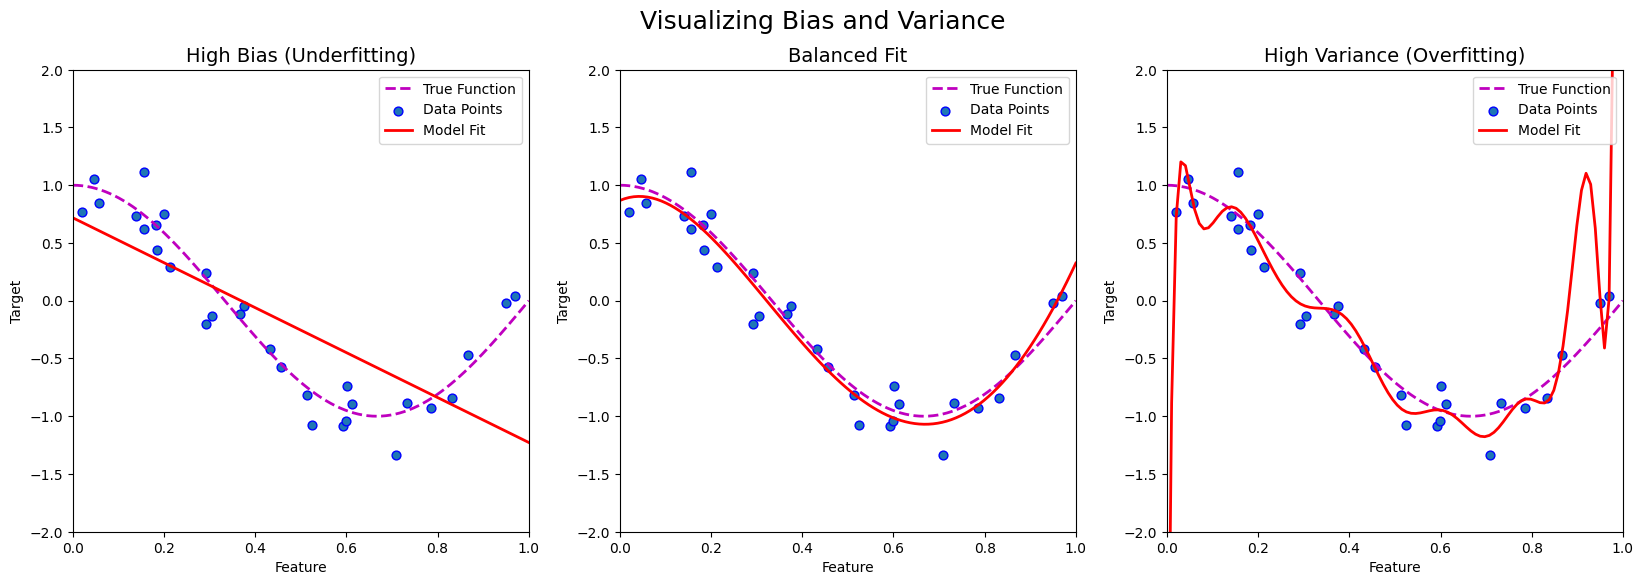

In [ ]:
# Create a figure to compare model fits
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plt.suptitle("Visualizing Bias and Variance", fontsize=18)

# Define degrees for underfit, good fit, and overfit models
degrees = [1, 4, 15]
titles = ["High Bias (Underfitting)", "Balanced Fit", "High Variance (Overfitting)"]

for i, degree in enumerate(degrees):
    ax = axes[i]

    # Create and fit a polynomial regression model
    pipeline = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    pipeline.fit(X[:, np.newaxis], y)

    # Plot the true function, data points, and model fit
    X_test = np.linspace(0, 1, 100)
    ax.plot(X_test, true_func(X_test), label="True Function", color='m', linestyle='--', linewidth=2)
    ax.scatter(X, y, edgecolor='b', s=40, label="Data Points")
    ax.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model Fit", color='red', linewidth=2)

    ax.set_xlabel("Feature")
    ax.set_ylabel("Target")
    ax.set_xlim((0, 1))
    ax.set_ylim((-2, 2))
    ax.legend(loc="upper right")
    ax.set_title(titles[i], fontsize=14)

plt.show()

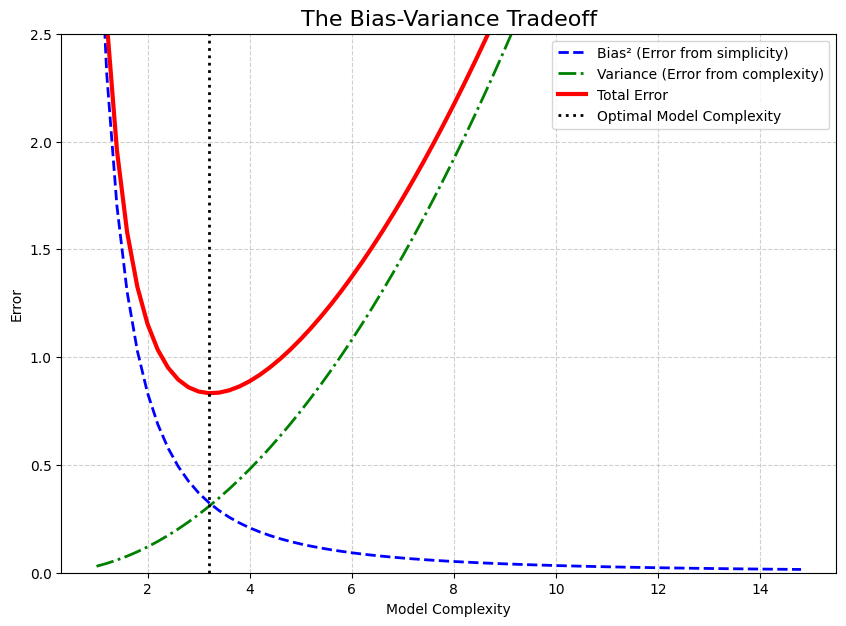

In [ ]:
# Create a figure for the conceptual tradeoff curve
plt.figure(figsize=(10, 7))

# Generate representative curves for bias, variance, and error
complexity = np.arange(1.0, 15.0, 0.2)
bias_squared = 1 / (0.3 * complexity**2)
variance = 0.03 * complexity**2
irreducible_error = np.full_like(complexity, 0.2)
total_error = bias_squared + variance + irreducible_error

# Find the point of minimum total error
min_error_idx = np.argmin(total_error)
optimal_complexity = complexity[min_error_idx]

# Plot the curves
plt.plot(complexity, bias_squared, 'b--', label='Bias² (Error from simplicity)', linewidth=2)
plt.plot(complexity, variance, 'g-.', label='Variance (Error from complexity)', linewidth=2)
plt.plot(complexity, total_error, 'r-', label='Total Error', linewidth=3)
plt.axvline(optimal_complexity, color='k', linestyle=':',
            label=f'Optimal Model Complexity', linewidth=2)

plt.xlabel('Model Complexity')
plt.ylabel('Error')
plt.title('The Bias-Variance Tradeoff', fontsize=16)
plt.legend()
plt.ylim(0, 2.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 3. Bagging (Bootstrap Aggregating)

Bagging is one of the foundational ensemble techniques. The core idea is to train multiple models of the same type (e.g., decision trees) independently on different subsets of the training data. The final prediction is then made by averaging (for regression) or taking a majority vote (for classification) of the individual model predictions.

![Pull yourself up by your bootstraps](https://img.huffingtonpost.com/asset/5b6b3e792000009f00379402.jpeg?ops=scalefit_1440&format=webp)

Refer to: [Why The Phrase 'Pull Yourself Up By Your Bootstraps' Is Nonsense](https://www.huffpost.com/entry/pull-yourself-up-by-your-bootstraps-nonsense_n_5b1ed024e4b0bbb7a0e037d4) for an understanding of this phrase.

### 3.1 How it works

1.  **Bootstrapping:** Create multiple (e.g., 100 or 500) new training datasets by randomly sampling with replacement from the original training data. Each new dataset will be roughly the same size as the original but will contain some duplicate records and miss some others.
2.  **Model Training:** Train an independent base model (e.g., a decision tree) on each of these bootstrapped datasets.
3.  **Aggregation:**
    * **Classification:** For a new data point, each base model makes a prediction. The class with the most votes wins.
    * **Regression:** For a new data point, each base model makes a prediction. The final prediction is the average of all individual predictions.

Bagging primarily helps to **reduce variance** without significantly increasing bias. By averaging out the predictions of many different models (each trained on slightly different data), the errors and noise from individual models tend to cancel each other out.

![Bootstrapping Aggregating](https://upload.wikimedia.org/wikipedia/commons/thumb/c/c8/Ensemble_Bagging.svg/1000px-Ensemble_Bagging.svg.png)

### 3.2 Random Forest

**Random Forest** is arguably the most popular and successful bagging algorithm. It enhances the basic bagging approach by introducing an additional layer of randomness:

* **Feature Randomness:** When growing each tree, instead of considering all possible features for the best split, only a random subset of features is considered at each node.

This feature randomness is crucial because it further **decorrelates** the individual trees. If trees were trained on the same features, they might end up making similar errors. By forcing them to consider different feature subsets, their errors become more independent, leading to a more robust ensemble.

**Advantages of Random Forests:**
* Excellent accuracy and robustness.
* Resistant to overfitting (due to averaging and feature randomness).
* Can handle a large number of features.
* Can work with both categorical and numerical features.
* Provides feature importance scores.

Let's see an example with `scikit-learn`.

In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("Libraries loaded successfully!")

Libraries loaded successfully!


### 3.3 Example: Classifying Moons Dataset with a Single Decision Tree vs. Random Forest

We'll use the `make_moons` dataset, which is a classic non-linear classification problem, to highlight the differences.

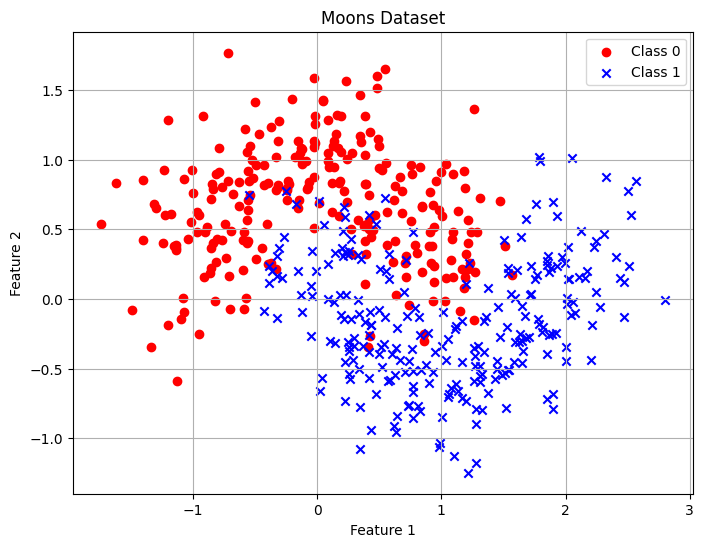

Dataset shape: X=(500, 2), y=(500,)


In [ ]:
# Generate dataset
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Plot the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], color='red', marker='o', label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', marker='x', label='Class 1')
plt.title('Moons Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

print(f"Dataset shape: X={X.shape}, y={y.shape}")

#### 3.3.1. Single Decision Tree

Single Decision Tree Accuracy: 0.8600


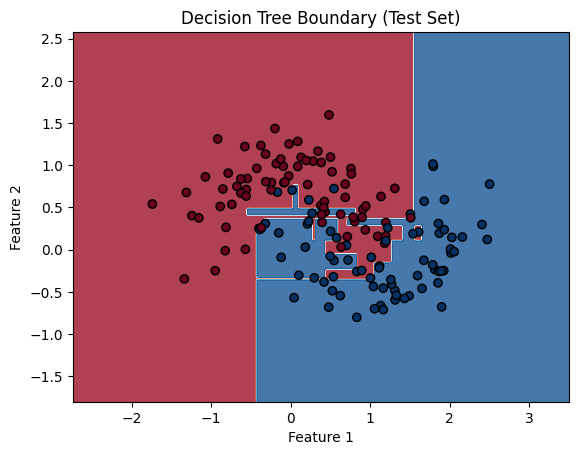

In [ ]:
# Train a single Decision Tree Classifier
single_tree = DecisionTreeClassifier(max_depth=10, random_state=42)
single_tree.fit(X_train, y_train)

# Predictions and accuracy
y_pred_tree = single_tree.predict(X_test)
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print(f"Single Decision Tree Accuracy: {accuracy_tree:.4f}")

# Plotting decision boundary for single tree
def plot_decision_boundary(clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors='k')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.show()

plot_decision_boundary(single_tree, X_test, y_test, 'Decision Tree Boundary (Test Set)')

# Visualize one of the smaller trees (if max_depth is small enough)
# plt.figure(figsize=(12, 8))
# plot_tree(single_tree, filled=True, feature_names=['Feature 1', 'Feature 2'], class_names=['Class 0', 'Class 1'])
# plt.title('Visualization of a Single Decision Tree')
# plt.show()

Notice how a single tree can create quite complex, sometimes jagged, decision boundaries, potentially leading to overfitting.

#### 3.3.2. Random Forest Classifier

Random Forest Classifier Accuracy: 0.9000


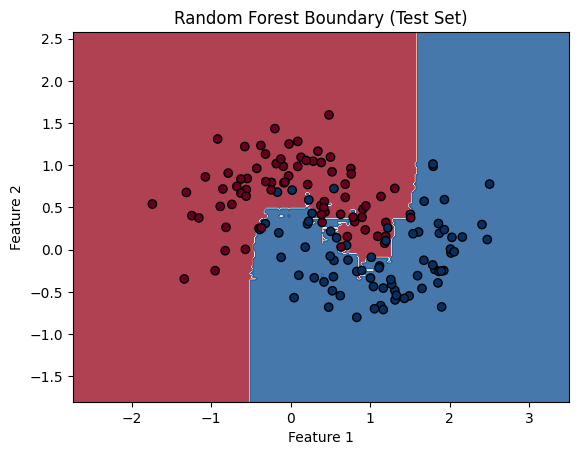

In [ ]:
# Train a Random Forest Classifier
random_forest = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
random_forest.fit(X_train, y_train)

# Predictions and accuracy
y_pred_rf = random_forest.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Classifier Accuracy: {accuracy_rf:.4f}")

# Plotting decision boundary for Random Forest
plot_decision_boundary(random_forest, X_test, y_test, 'Random Forest Boundary (Test Set)')

You should observe that the Random Forest generally achieves higher accuracy and produces a smoother, more generalized decision boundary compared to a single decision tree. This demonstrates its ability to reduce variance and improve generalization.

### 3.4 Feature Importance with Random Forest

A great benefit of tree-based ensembles is their ability to provide feature importance scores. This helps us understand which features contribute most to the model's predictions.

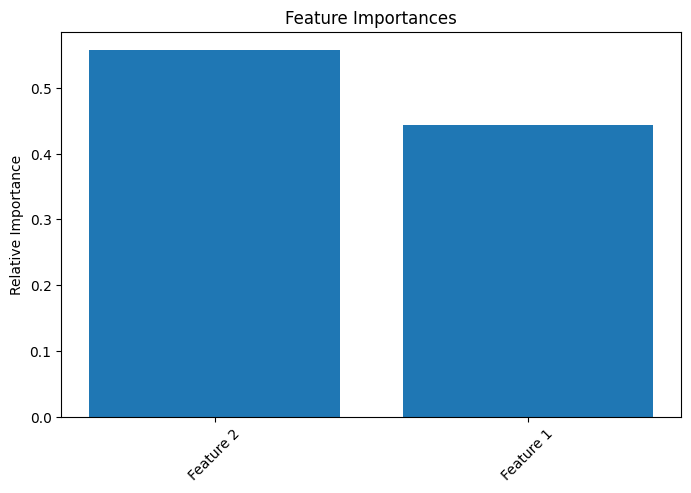

In [ ]:
# Get feature importances
importances = random_forest.feature_importances_
feature_names = ['Feature 1', 'Feature 2'] # Assuming these are our feature names

# Sort them in descending order
indices = np.argsort(importances)[::-1]

# Plot feature importance
plt.figure(figsize=(8, 5))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45)
plt.ylabel('Relative Importance')
plt.show()

## 4. Boosting: Sequential Error Correction

Boosting takes a different approach to ensemble learning compared to bagging. Instead of building models independently, boosting builds them **sequentially**, with each new model trying to correct the errors made by the previous ones. It's like having a team where each new member learns from the mistakes of the one before.



### 4.1 **General Boosting Idea:**

A typical boosting method includes the following steps:
- Train an initial (often simple or weak`) model on the data.
- Evaluate the model and identify where it made errors.
- Train a new model that focuses more on these previously misclassified or poorly predicted data points.
- Add the new model to the ensemble, often with a reduced weight, and repeat the process.

Boosting primarily helps to **reduce bias** and can create very powerful predictive models. However, it's more susceptible to overfitting if not carefully tuned, as it continuously tries to reduce errors on the training data.

### 4.2 Gradient Boosting Machines (GBM)

Gradient Boosting is a powerful and widely used form of boosting. Instead of explicitly re-weighting data points (like AdaBoost), it trains each new tree to predict the **residuals** (the errors or differences between the actual target values and the predictions of the current ensemble).

**Key Idea of GBM:**
1.  Start with an initial prediction (e.g., the average of the target variable).
2.  Calculate the residuals (actual - current prediction).
3.  Train a new decision tree to predict these residuals.
4.  Add the prediction of this new tree to the current ensemble's prediction, usually scaled by a small **learning rate** (this prevents overfitting and allows for gradual learning).
5.  Repeat steps 2-4 for a specified number of iterations.

GBM models are known for their high accuracy and flexibility. `scikit-learn` provides `GradientBoostingClassifier` and `GradientBoostingRegressor`.

Let's see an example.

Gradient Boosting Classifier Accuracy: 0.8867


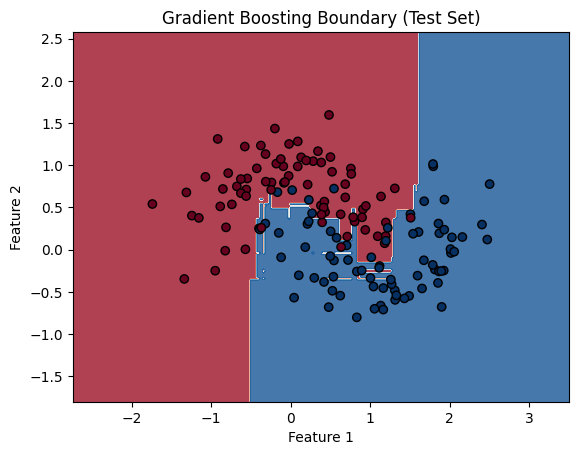

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Train a Gradient Boosting Classifier
# n_estimators: Number of boosting stages (trees)
# learning_rate: Shrinks the contribution of each tree
# max_depth: Limits the depth of individual trees (often shallow, e.g., 3-5)
gb_classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_classifier.fit(X_train, y_train)

# Predictions and accuracy
y_pred_gb = gb_classifier.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Classifier Accuracy: {accuracy_gb:.4f}")

# Plotting decision boundary for Gradient Boosting
plot_decision_boundary(gb_classifier, X_test, y_test, 'Gradient Boosting Boundary (Test Set)')

Gradient Boosting often achieves performance comparable to or even better than Random Forests, especially when carefully tuned. Its decision boundary tends to be smooth and precise.

### 4.3 XGBoost, LightGBM, CatBoost

These are highly optimized and widely used implementations of gradient boosting that offer significant performance improvements (speed and accuracy) over the base `sklearn` implementation, especially on large datasets.

* **XGBoost (eXtreme Gradient Boosting):** Known for its speed and accuracy, regularization techniques, and ability to handle missing values.
* **LightGBM (Light Gradient Boosting Machine):** Developed by Microsoft, it uses a leaf-wise tree growth algorithm (instead of level-wise) and is generally much faster than XGBoost on large datasets.
* **CatBoost (Categorical Boosting):** Developed by Yandex, it excels at handling categorical features natively without requiring extensive preprocessing like one-hot encoding.

In [ ]:
!pip install xgboost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [06:38:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Accuracy: 0.8867


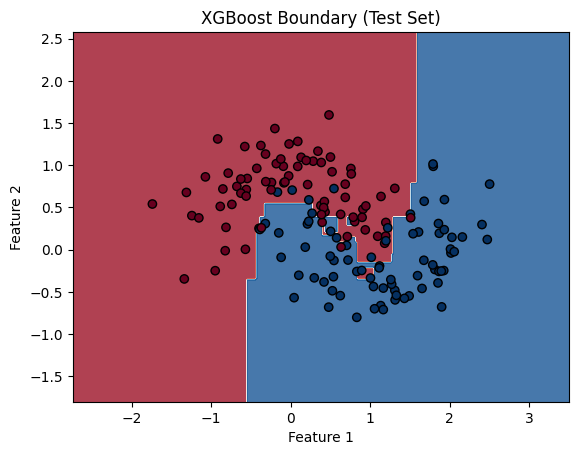

In [ ]:
from xgboost import XGBClassifier

xgb_classifier = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_classifier.fit(X_train, y_train)
y_pred_xgb = xgb_classifier.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Classifier Accuracy: {accuracy_xgb:.4f}")
plot_decision_boundary(xgb_classifier, X_test, y_test, 'XGBoost Boundary (Test Set)')

## 5. Model Evaluation and Hyperparameter Tuning ⚙️

After building models, it's crucial to evaluate their true performance and fine-tune their settings (hyperparameters) for optimal results. This section covers key techniques.

### 5.1 Cross-Validation

A simple train-test split gives us one estimate of model performance, but it can be sensitive to the particular split. **Cross-validation** provides a more robust estimate by training and evaluating the model multiple times on different subsets of the data.

**K-Fold Cross-Validation:**

1.  Divide the training data into `k` equally sized 'folds'.
2.  For each fold:
    * Use that fold as the validation set.
    * Use the remaining `k-1` folds as the training set.
    * Train the model on the training set and evaluate on the validation set.
3.  The final performance metric is the average of the `k` individual validation scores.

This helps ensure that our performance estimate is not just a fluke of a single data split and that our model generalizes well across different parts of the data.

In [ ]:
from sklearn.model_selection import cross_val_score, KFold

# Define the model (e.g., Random Forest)
model_for_cv = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Define the cross-validation strategy
# n_splits: Number of folds (e.g., 5 or 10)
# shuffle: Shuffle the data before splitting
# random_state: For reproducibility of shuffling
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
# X, y here should be your *entire* training dataset, or even the full dataset if you're just evaluating
# For this example, let's use the full X, y from make_moons
cv_scores = cross_val_score(model_for_cv, X, y, cv=kf, scoring='accuracy')

print(f"Cross-validation scores: {cv_scores}")
print(f"Average cross-validation accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard deviation of cross-validation accuracy: {np.std(cv_scores):.4f}")

Cross-validation scores: [0.87 0.92 0.93 0.9  0.91]
Average cross-validation accuracy: 0.9060
Standard deviation of cross-validation accuracy: 0.0206


### 5.2 Hyperparameter Tuning

Machine learning models have parameters that are learned from the data (e.g., the weights in a linear regression). They also have **hyperparameters**, which are settings that are *not* learned from data but are set by the user *before* training (e.g., `n_estimators`, `max_depth`, `learning_rate`). The right hyperparameters can significantly impact model performance.

#### 5.2.1. Grid Search (`GridSearchCV`)

**Grid Search** exhaustively tries every possible combination of hyperparameters defined in a grid. It's thorough but can be computationally expensive for many hyperparameters or large ranges.

**How it works:**
1.  Define a dictionary of hyperparameters and the specific values to test for each.
2.  `GridSearchCV` trains a model for *every single combination* of these values.
3.  For each combination, it performs cross-validation to get a robust performance score.
4.  It then selects the combination of hyperparameters that yielded the best average cross-validation score.

Starting Grid Search... (This might take a moment)
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Grid Search completed.
Best parameters found: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation accuracy: 0.9200
Test set accuracy with best parameters: 0.9067


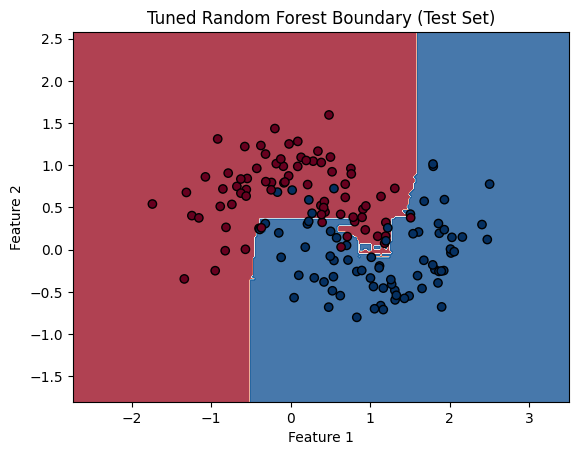

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the model
rf_model_gs = RandomForestClassifier(random_state=42)

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [5, 10, None],      # Maximum depth of the tree (None means unlimited)
    'min_samples_split': [2, 5]      # Minimum number of samples required to split an internal node
}

# Create GridSearchCV object
# estimator: The model to tune
# param_grid: The dictionary of parameters to test
# cv: Cross-validation strategy
# scoring: Metric to optimize (e.g., 'accuracy', 'f1', 'roc_auc')
# n_jobs: Number of CPU cores to use (-1 means all available)
grid_search = GridSearchCV(estimator=rf_model_gs, param_grid=param_grid, cv=kf, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit Grid Search to the training data
print("Starting Grid Search... (This might take a moment)")
grid_search.fit(X_train, y_train)

print("\nGrid Search completed.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Get the best model
best_rf_model = grid_search.best_estimator_

# Evaluate on the test set
y_pred_tuned = best_rf_model.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Test set accuracy with best parameters: {accuracy_tuned:.4f}")

plot_decision_boundary(best_rf_model, X_test, y_test, 'Tuned Random Forest Boundary (Test Set)')

#### 5.2.2. Random Search (`RandomizedSearchCV`)

**Random Search** samples a fixed number of hyperparameter settings from specified distributions. It's often more efficient than grid search, especially when only a few hyperparameters significantly impact performance, as it can explore more of the parameter space randomly rather than exhaustively.

**How it works:**
1.  Define a dictionary of hyperparameters, but instead of specific values, define distributions (e.g., `scipy.stats.randint`, `scipy.stats.uniform`).
2.  Specify `n_iter`, the number of random combinations to try.
3.  `RandomizedSearchCV` samples `n_iter` combinations, trains models with cross-validation for each, and selects the best.

Starting Random Search... (This might take a moment)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Random Search completed.
Best parameters found: {'learning_rate': np.float64(0.04410482473745831), 'max_depth': 2, 'n_estimators': 181, 'subsample': np.float64(0.9826605267054558)}
Best cross-validation accuracy: 0.9171
Test set accuracy with best parameters: 0.9067


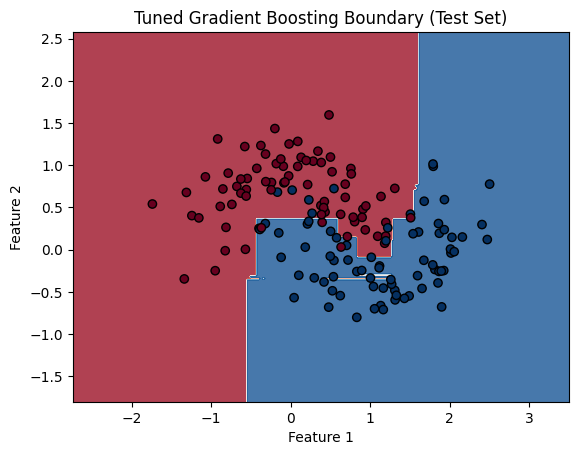

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Define the model
gb_model_rs = GradientBoostingClassifier(random_state=42)

# Define the parameter distributions to sample from
param_distributions = {
    'n_estimators': randint(50, 300),          # Integer distribution for number of trees
    'learning_rate': uniform(0.01, 0.2),       # Float distribution for learning rate
    'max_depth': randint(1, 6),                # Integer distribution for tree depth
    'subsample': uniform(0.7, 0.3)             # Fraction of samples used for fitting the individual base learners
}

# Create RandomizedSearchCV object
# n_iter: Number of parameter settings that are sampled (trade-off between runtime and accuracy)
random_search = RandomizedSearchCV(estimator=gb_model_rs, param_distributions=param_distributions,
                                   n_iter=20, cv=kf, scoring='accuracy', n_jobs=-1, verbose=1, random_state=42)

# Fit Random Search to the training data
print("Starting Random Search... (This might take a moment)")
random_search.fit(X_train, y_train)

print("\nRandom Search completed.")
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best cross-validation accuracy: {random_search.best_score_:.4f}")

# Get the best model
best_gb_model = random_search.best_estimator_

# Evaluate on the test set
y_pred_tuned_gb = best_gb_model.predict(X_test)
accuracy_tuned_gb = accuracy_score(y_test, y_pred_tuned_gb)
print(f"Test set accuracy with best parameters: {accuracy_tuned_gb:.4f}")

plot_decision_boundary(best_gb_model, X_test, y_test, 'Tuned Gradient Boosting Boundary (Test Set)')

## 6. The Bias-Variance Tradeoff

Understanding the bias-variance tradeoff is fundamental to comprehending why different models perform the way they do and how ensemble methods address specific types of errors.

**Imagine fitting a model to data as trying to hit a target.**

* **Bias:** Represents the error introduced by approximating a real-world problem, which may be complex, by a much simpler model. High bias means your model consistently misses the center of the target (e.g., always predicting too low or too high). It leads to **underfitting**.
    * *Analogy:* Aiming at the wrong spot, consistently missing the bullseye in the same direction.
    * *Examples:* A linear model trying to fit non-linear data; a very shallow decision tree.

* **Variance:** Represents the error due to the model's sensitivity to small fluctuations in the training data. High variance means your model's predictions are scattered widely around the target, even if the average is on target. It leads to **overfitting**.
    * *Analogy:* Your shots are all over the place, but on average, they might hit the bullseye. However, any single shot is unpredictable.
    * *Examples:* A very deep decision tree that memorizes the training data; a complex neural network trained on a small dataset.

**The Goal:** Find a sweet spot (a good tradeoff) where both bias and variance are low, leading to good generalization performance on unseen data. 🎯

### How Ensemble Methods Address Bias and Variance:

1.  **Single Decision Tree (CART):**
    * **Bias:** Relatively low (can capture complex patterns).
    * **Variance:** **High** (very sensitive to training data, prone to overfitting).
    * *Summary:* A single deep tree is like a very precise shooter who is easily distracted and aims differently each time, resulting in scattered shots.

2.  **Random Forest (Bagging):**
    * **Effect:** Primarily **reduces variance**.
    * **How:** By averaging the predictions of many independently trained, high-variance (but low-bias) trees, the random errors and fluctuations tend to cancel each other out. The overall model becomes much more stable.
    * *Summary:* It's like having many independently trained shooters, each with their own minor aiming errors. By averaging their shots, the overall prediction becomes much more accurate and consistent.

3.  **Gradient Boosting (Boosting):**
    * **Effect:** Primarily **reduces bias**.
    * **How:** It sequentially builds models, with each new model focusing on correcting the *errors* (residuals) of the previous ensemble. It starts with simple, high-bias models and gradually adds complexity to capture more intricate patterns, thereby reducing the overall bias of the combined model.
    * *Summary:* It's like having a team of shooters. The first one takes a shot. The next one observes where the first one missed and tries to correct that specific error. This continues, gradually refining the aim and reducing systemic biases.

Understanding this tradeoff is key to selecting the right model and tuning its hyperparameters effectively. When your model is underfitting, you might need to increase model complexity or reduce bias (e.g., use more complex features, switch to boosting). When your model is overfitting, you need to reduce variance (e.g., add regularization, use more data, switch to bagging/Random Forest, or simplify your model).